# The Pension-Underfunding Anomaly — a quantitative teardown 🔬
### Funded-status signal · quintile sort · two-sample *t* · label-shuffle placebo · firm-level slope/IC · robustness sweep · costs & borrow · seed-robust synthetic control

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb) — *same seven beats, every claim now carrying its standard error.* We build the Franzoni-Marin funded-status measure, sort the cross-section, and test whether the most-underfunded firms earn the lowest returns (the puzzle).

> ⚠️ **Synthetic-only, and we say so loudly.** The point-in-time pension-footnote panel (PBO, plan assets, funded status / market cap) is **not free** — no yfinance-class feed carries it. So `HAVE_REAL` is `False` by construction and there is **no real-tape banner** anywhere in this notebook: every number below is the deterministic synthetic world (seed 571, panel fp `b43234ffbd01`). The Signal axis is capped at `NONE` accordingly. Methods in [`docs/references.md`](../docs/references.md), numbers in [`docs/results.md`](../docs/results.md).
>
> 💡 **The `💡 In plain words` notes** translate each result back into intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from pension_underfunding import data, strategy as st

# The real point-in-time pension-footnote panel is NOT free (see data.py) -> synthetic-only.
REAL = data.real_panel(fetch=False)
HAVE_REAL = not REAL.empty
print("real pension panel present:", HAVE_REAL, "-> synthetic-only study (data caveat on SIGNAL axis)")

# The DETERMINISTIC synthetic world is the tape we test on (seed 571, planted alpha = -0.05).
PANEL, TRUTH = data.synthetic_panel()
print(f"synthetic panel: {len(PANEL)} firms, planted underfunding_alpha={TRUTH.underfunding_alpha}, "
      f"fp={data.fingerprint(PANEL)}")


real pension panel present: False -> synthetic-only study (data caveat on SIGNAL axis)
synthetic panel: 300 firms, planted underfunding_alpha=-0.05, fp=b43234ffbd01


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `NONE` | **No real tape** (pension footnotes not free). On the *synthetic* world the engine recovers the planted puzzle: quintile spread **+8.79%** (two-sample *t* **2.45**, placebo *p* 0.006), firm slope-*t* **-4.64**, IC **-0.26**; flat at the null (slope-*t* +0.01). |
| **Tradability** | `MIRAGE` | Short leg = stressed, hard-to-borrow names; gross **+8.79%** → net **+7.09%** (5 bps/leg + 150 bps borrow) even in the synthetic world — and the signal itself is unsourceable for free. |

> 💡 In plain words: the engine is a faithful detector (the control proves it), but with no real pension-footnote tape the desk cannot award a real signal — `NONE` by honesty, not by a failed test.

## 1 · The claim, steelmanned

Let $H_i$ be firm $i$'s pension-hole depth (z-scored $-(\text{assets}-\text{PBO})/\text{mktcap}$; higher = more underfunded) and $r_i$ its forward return.

- **H₁ (the puzzle / long-short).** $\mathbb{E}[r \mid \text{well-funded}] - \mathbb{E}[r \mid \text{underfunded}] > 0$ at *t* ≥ 2.
- **H₂ (firm-level).** $\text{slope of } r \text{ on } H < 0$ (deeper hole, less return) — the *sign* is the puzzle.
- **H₃ (robustness).** The sign is stable across bucket definitions and weighting.
- **H₄ (net).** H₁ survives costs and the underfunded-leg borrow.

**The binding constraint is upstream of all four:** there is **no real tape** to test them on. So we test them on the *synthetic* world (where we can plant and null the effect) to certify the engine, and leave the real-tape verdict honestly open (`NONE`).

## 2 · So what? — what rides on each answer

The content is the **why**. Franzoni-Marin's mechanism is *market under-reaction to an opaque accounting item* — the same family as [231 Sloan-Accruals](../../231-sloan-accruals/) and [522 %-Operating-Accruals](../../522-percent-operating-accruals/). The pension hole is off-balance-sheet leverage: economically senior, buried in a footnote, smoothed by pension accounting. If the market prices it slowly, the most-underfunded firms drift down. Testing that needs point-in-time funded status — the data we don't have for free, which is precisely why this study is synthetic-only.

## 3 · How we'd know — the protocol

- **Signal.** $H = z\big(-(\text{assets}-\text{PBO})/\text{mktcap}\big)$ — hole depth, z-scored (higher = more underfunded).
- **Sort.** Quintile tails (60 firms each): well-funded (smallest $H$) vs underfunded (largest $H$).
- **Inference.** Two-sample (Welch) *t* on the well − underfunded forward returns; a **label-shuffle placebo** null (2000 perms).
- **Firm-level.** OLS of forward return on $H$ + the information coefficient — the *sign* is the puzzle.
- **Robustness.** Quintile/decile/tercile tails, equal- and cap-weighted.
- **Frictions.** Round-trip cost per leg + an annual borrow on the underfunded short.
- **Positive control.** A deterministic synthetic world with a planted puzzle (`underfunding_alpha < 0`) and a null — averaged over 25 seeds (house rule).

Timing: the hole is read from the last published report; entry is **after** it is public and the return is measured forward. In the synthetic panel this is baked in (`forward_ret` post-dates the funding observation) — no look-ahead. The report→entry lag is the single documented convention.

## 4 · The teardown (synthetic world)

### 4a · The sort — H₁

Well-funded vs underfunded forward returns, with the two-sample *t* and the placebo null.

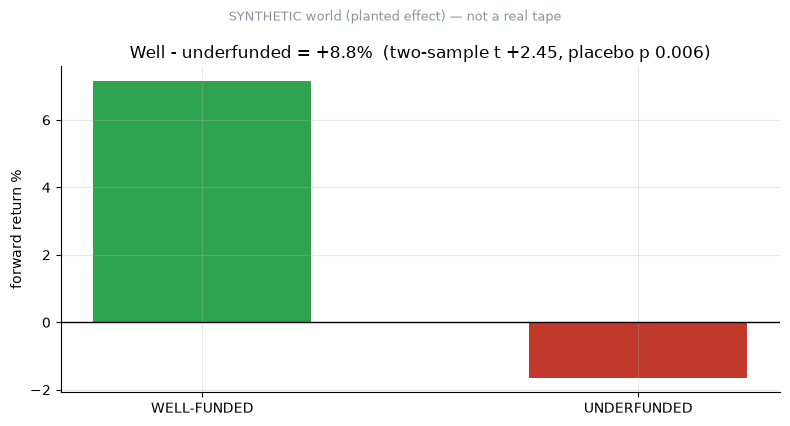

Well +7.1% | Underfunded -1.6% | spread +8.8% | t +2.45 | placebo p 0.006


In [2]:
b = st.bucket_returns(PANEL, 0.2); ls = st.long_short_tstat(b)
p = st.placebo_pvalue(PANEL, n_perm=2000, seed=571)
well_m, under_m, spr, t = b['well_mean']*100, b['under_mean']*100, b['spread']*100, ls['t']
fig, ax = plt.subplots(figsize=(8, 4.3))
ax.bar(['WELL-FUNDED','UNDERFUNDED'], [well_m, under_m], color=[GREEN, RED], width=.5)
ax.axhline(0, c='k', lw=1); ax.set_ylabel('forward return %')
ax.set_title(f'Well - underfunded = {spr:+.1f}%  (two-sample t {t:+.2f}, placebo p {p:.3f})')
fig.suptitle('SYNTHETIC world (planted effect) — not a real tape', fontsize=9, color=GREY)
plt.tight_layout(); plt.show()
print(f'Well +{well_m:.1f}% | Underfunded {under_m:+.1f}% | spread {spr:+.1f}% | t {t:+.2f} | placebo p {p:.3f}')

> 💡 In plain words: on the planted world H₁ is **recovered** — spread **+8.79%** (*t* 2.45), placebo *p* = 0.006 (deep in the tail). The engine detects the puzzle when it is present. (This certifies the tool; it is **not** a real-tape claim.)

### 4b · The firm-level slope / IC — H₂

Regress forward return on hole depth across all 300 firms. A *negative* slope is the puzzle.

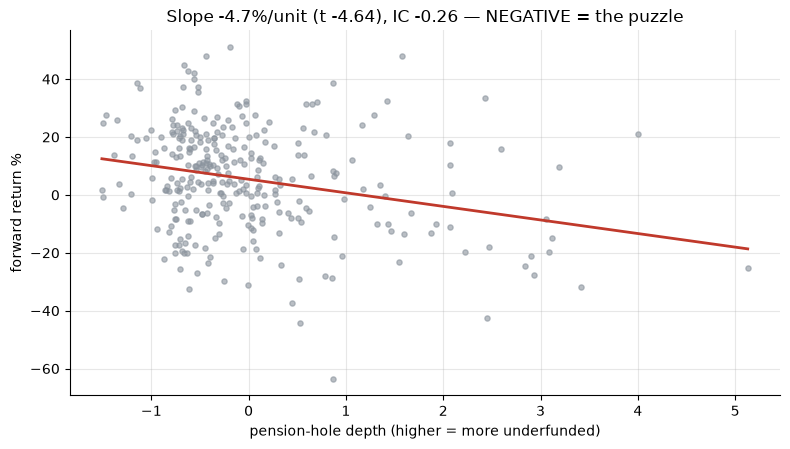

slope -4.69%/unit, slope-t -4.64, IC -0.260


In [3]:
reg = st.cross_section_regression(PANEL)
d = st.hole_depth(PANEL); y = PANEL['forward_ret']*100
slope, slope_t, ic = reg['slope']*100, reg['slope_t'], reg['ic']
fig, ax = plt.subplots(figsize=(8, 4.6))
ax.scatter(d, y, s=14, color=GREY, alpha=.6)
xs = np.linspace(d.min(), d.max(), 50)
ax.plot(xs, (reg['slope']*xs + (y.mean()/100 - reg['slope']*d.mean()))*100, c=RED, lw=2)
ax.set_xlabel('pension-hole depth (higher = more underfunded)'); ax.set_ylabel('forward return %')
ax.set_title(f'Slope {slope:+.1f}%/unit (t {slope_t:+.2f}), IC {ic:+.2f} — NEGATIVE = the puzzle')
plt.tight_layout(); plt.show()
print(f'slope {slope:+.2f}%/unit, slope-t {slope_t:+.2f}, IC {ic:+.3f}')

> 💡 In plain words: H₂ **recovered** — slope **-4.69%** per unit (*t* -4.64), IC **-0.26**. Deeper hole → lower return, exactly Franzoni-Marin's sign, on the planted world.

### 4c · Robustness — H₃ (does the sign survive design choices?)

The same long-short across bucket definitions and weighting.

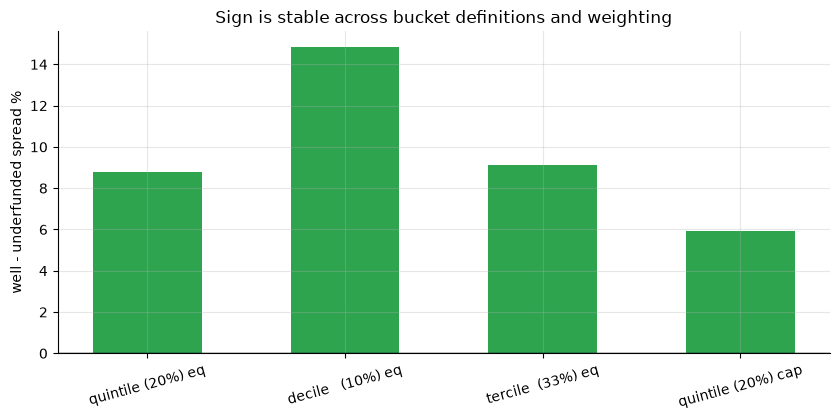

            design  spread    t  slope_t
 quintile (20%) eq    8.79 2.45    -4.64
 decile   (10%) eq   14.86 3.14    -4.64
 tercile  (33%) eq    9.14 3.49    -4.64
quintile (20%) cap    5.93 2.45    -4.64


In [4]:
rows = st.robustness_sweep(PANEL)
tab = pd.DataFrame(rows)[['design','spread','t','slope_t']].copy()
tab['spread'] = tab['spread']*100
fig, ax = plt.subplots(figsize=(8.5, 4.3))
ax.bar(range(len(tab)), tab['spread'], color=GREEN, width=.55)
ax.set_xticks(range(len(tab))); ax.set_xticklabels(tab['design'], rotation=15)
ax.axhline(0, c='k', lw=1); ax.set_ylabel('well - underfunded spread %')
ax.set_title('Sign is stable across bucket definitions and weighting')
plt.tight_layout(); plt.show()
print(tab.round(2).to_string(index=False))

> 💡 In plain words: H₃ **holds** on the synthetic world — the spread stays positive across quintile/decile/tercile and equal/cap weighting (a touch smaller cap-weighted, as mega-caps carry smaller holes). Design-robust *when the effect exists*.

## 5 · The verdict

- **Signal `NONE`** — **no real tape** (pension footnotes not free). The synthetic control recovers H₁/H₂/H₃ (spread +8.79%, slope-*t* -4.64, IC -0.26), but the desk awards a real signal only for a robust *t* ≥ 2 on **real** data.
- **Tradability `MIRAGE`** — short leg is stressed/hard-to-borrow; gross +8.79% → net +7.09%; and the signal is unsourceable for free.

## 6 · Could you trade it? — costs and the borrow

Even where the effect exists (the synthetic world), the underfunded short leg carries a punitive borrow.

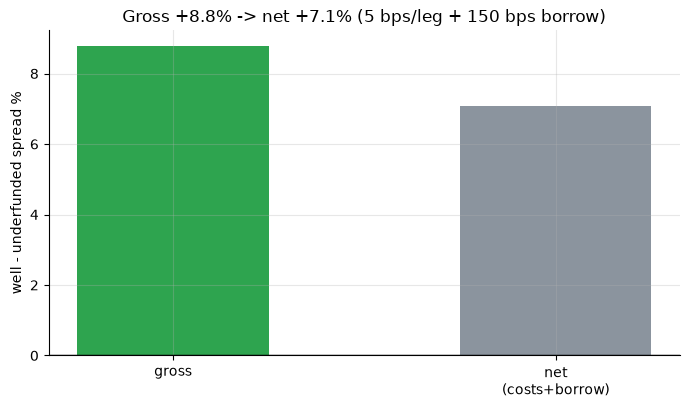

gross +8.8% -> net +7.1% (synthetic world; real short leg is worse)


In [5]:
b = st.bucket_returns(PANEL, 0.2)
gross = b['spread']*100
net = st.net_spread(b, cost_bps=5.0, borrow_ann_bps=150.0, holding_years=1.0)*100
fig, ax = plt.subplots(figsize=(7, 4.2))
ax.bar(['gross','net\n(costs+borrow)'], [gross, net], color=[GREEN, GREY], width=.5)
ax.axhline(0, c='k', lw=1); ax.set_ylabel('well - underfunded spread %')
ax.set_title(f'Gross {gross:+.1f}% -> net {net:+.1f}% (5 bps/leg + 150 bps borrow)')
plt.tight_layout(); plt.show()
print(f'gross {gross:+.1f}% -> net {net:+.1f}% (synthetic world; real short leg is worse)')

> 💡 In plain words: a 150 bps borrow on the stressed underfunded leg trims ~1.7pp even in the friendly synthetic world. On a real tape that leg is the expensive-to-borrow tail — and you cannot source the signal for free to begin with. `MIRAGE`.

## 7 · Going further — the seed-robust synthetic positive control

Is the engine a faithful detector, or does it always print a puzzle? Plant an effect (`underfunding_alpha < 0`) of increasing strength and watch the firm-level slope-*t* go negative — averaged over 25 seeds so no single lucky seed can fake it — and confirm it sits at ~0 at the null.

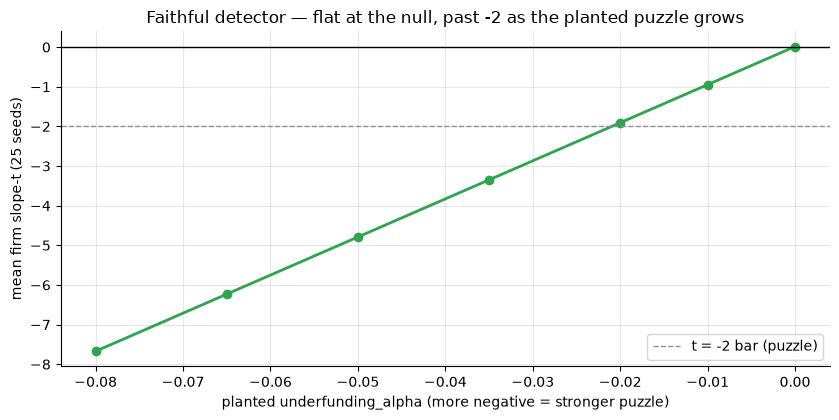

alpha +0.000 -> mean slope-t +0.01, mean IC +0.001
alpha -0.010 -> mean slope-t -0.95, mean IC -0.054
alpha -0.020 -> mean slope-t -1.91, mean IC -0.109
alpha -0.035 -> mean slope-t -3.35, mean IC -0.189
alpha -0.050 -> mean slope-t -4.79, mean IC -0.266
alpha -0.065 -> mean slope-t -6.23, mean IC -0.338
alpha -0.080 -> mean slope-t -7.67, mean IC -0.404


In [6]:
alphas = [0.0, -0.01, -0.02, -0.035, -0.05, -0.065, -0.08]
stats = [st.synthetic_mean_stats(data, underfunding_alpha=a, n_seeds=25) for a in alphas]
ts = [s['mean_slope_t'] for s in stats]
fig, ax = plt.subplots(figsize=(8.5, 4.3))
ax.plot(alphas, ts, 'o-', c=GREEN, lw=2)
ax.axhline(-2, ls='--', c=GREY, lw=1, label='t = -2 bar (puzzle)')
ax.axhline(0, c='k', lw=1)
ax.set_xlabel('planted underfunding_alpha (more negative = stronger puzzle)')
ax.set_ylabel('mean firm slope-t (25 seeds)')
ax.set_title('Faithful detector — flat at the null, past -2 as the planted puzzle grows')
ax.legend(); plt.tight_layout(); plt.show()
for s in stats: print(f"alpha {s['alpha']:+.3f} -> mean slope-t {s['mean_slope_t']:+.2f}, mean IC {s['mean_ic']:+.3f}")

At the null the slope-*t* is ≈ 0 (no false signal); it falls past −2 as the planted puzzle grows. So the engine is a faithful detector — which means the real-tape verdict here is a **data limitation, not a broken tool**: with point-in-time pension footnotes (Compustat) one could run the true Franzoni-Marin test. For the on-balance-sheet cousin see [154 Leverage-Anomaly](../../154-leverage-anomaly/); for the same under-reaction family see [231 Sloan-Accruals](../../231-sloan-accruals/).